In [1]:
# A. Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv("netflix_titles.csv")
# Check basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
# B. Data Cleaning – Duration Column
# Step 1: Remove non-numeric text from duration
# This handles values like "90 min", "2 Seasons", "1 Season", etc.

In [5]:
# Extract only numeric values from the duration column
df['duration_clean'] = df['duration'].str.extract('(\d+)').astype(float)

# Convert to numeric type
df['duration_clean'] = pd.to_numeric(df['duration_clean'], errors='coerce')

# Check missing values after cleaning
df['duration_clean'].isnull().sum()

np.int64(3)

In [6]:
# Step 2: Drop rows with missing values (needed for clustering)

In [7]:
# Keep only rows where release_year and duration are available
df_clean = df.dropna(subset=['release_year', 'duration_clean']).copy()


# Check final shape
df_clean.shape

(8804, 13)

In [8]:
# C. Data Exploration – Visualizations

In [9]:
# 1. Content Growth Over Time (Release Year Distribution)

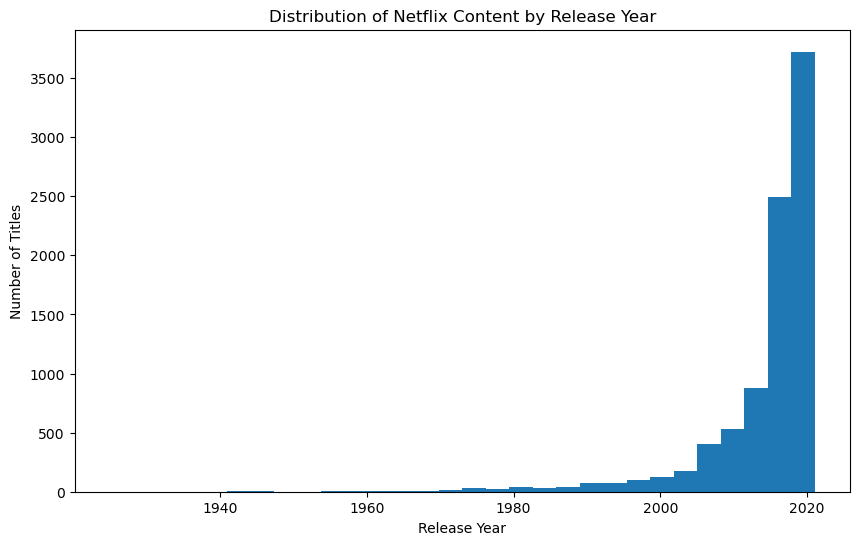

In [10]:
plt.figure(figsize=(10,6))
plt.hist(df_clean['release_year'], bins=30)
plt.title("Distribution of Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [11]:
# 2. Missing Values Heatmap

In [12]:
# Create Missing Values Heatmap

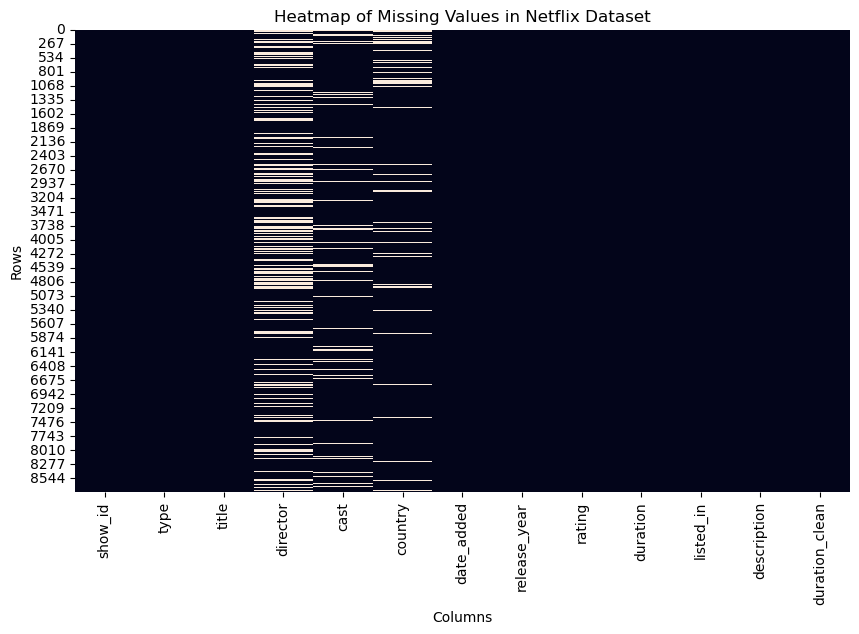

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Heatmap of Missing Values in Netflix Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [14]:
# 3. Duration Distribution

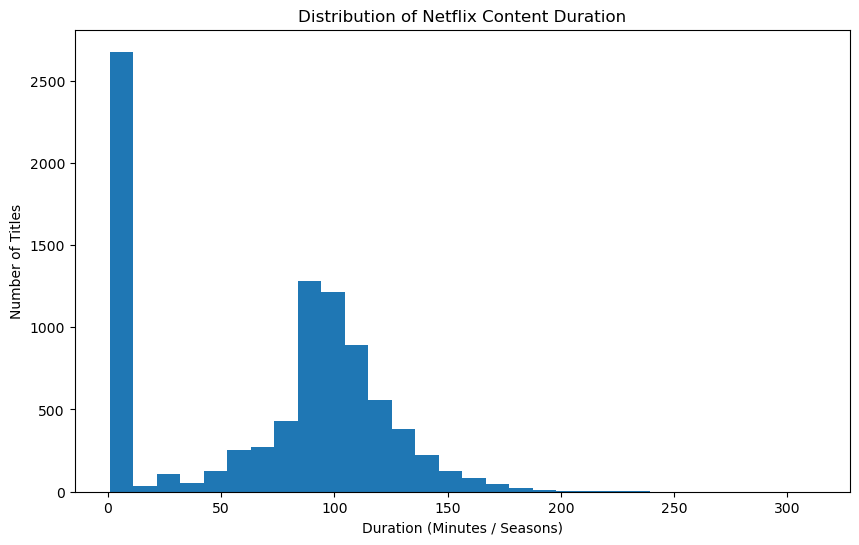

In [15]:
plt.figure(figsize=(10,6))
plt.hist(df_clean['duration_clean'], bins=30)
plt.title("Distribution of Netflix Content Duration")
plt.xlabel("Duration (Minutes / Seasons)")
plt.ylabel("Number of Titles")
plt.show()

In [16]:
# 4. Movie vs TV Show Count

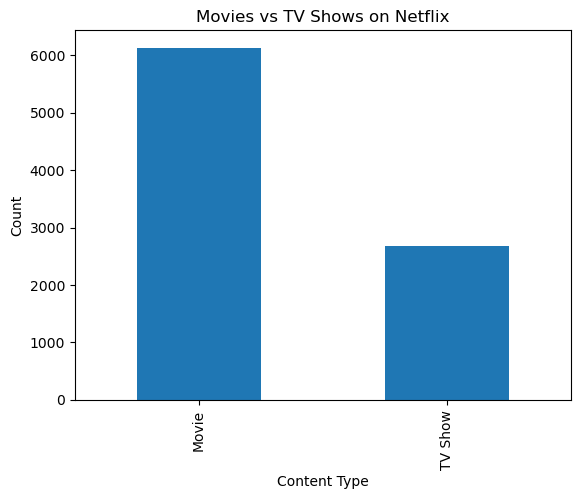

In [17]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

In [18]:
# D. Data Mining & Analysis – K-Means Clustering

In [19]:
# Step 1: Feature Selection

In [20]:
# We use: release_year, duration_clean

In [21]:
X = df_clean[['release_year', 'duration_clean']]

In [22]:
# Step 2: Feature Scaling

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [24]:
# Step 3: Apply K-Means Clustering

In [25]:
# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster counts
df_clean['cluster'].value_counts()

cluster
0    4522
1    2939
2    1064
3     279
Name: count, dtype: int64

In [26]:
# Step 4: Cluster Visualization

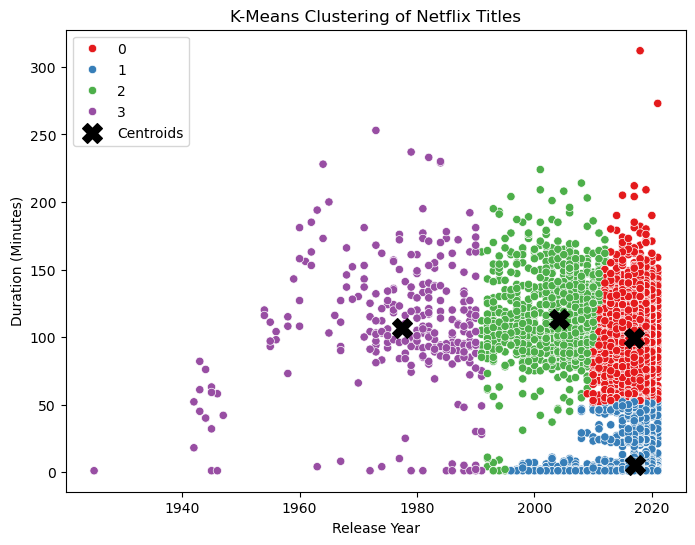

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_clean['release_year'],
    y=df_clean['duration_clean'],
    hue=df_clean['cluster'],
    palette='Set1'
)

# Get cluster centers (convert back to original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=200,
    c='black',
    label='Centroids'
)

plt.title('K-Means Clustering of Netflix Titles')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.legend()
plt.show()

In [28]:
# E. Simple Cluster Interpretation

In [29]:
df_clean.groupby('cluster')[['release_year', 'duration_clean']].mean()

,release_year,duration_clean
cluster,,
0,2016.934542,99.429677
1,2017.041511,5.055121
2,2004.179511,113.381579
3,1977.537634,106.867384
